In [9]:
%load_ext autoreload
%autoreload 2

from plot import load_outputs, plot_final_loss_vs_lr, plot_tuned_curves
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import json, glob, re, os
import numpy as np

mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
plt.rc('text', usetex=False)
plt.rc('mathtext', fontset='cm')
plt.rc('legend', fontsize=10)

colormap = {
    'muon':       '#8A2BE2',
    'adamw':      '#FF6B35',
    'dap-opnorm': '#1f77b4',
}

os.makedirs('figures', exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Baseline LR Sensitivity: Muon vs AdamW (fineweb1B, GPT-tiny)

In [10]:
hydra_base_muon  = 'outputs/gpt-tiny/fineweb1B/muon'
hydra_base_adamw = 'outputs/gpt-tiny/fineweb1B/adamw'

def load_hydra_lr_sweep(base_dir, label):
    """Load all runs from a Hydra LR sweep directory, labeling by LR."""
    results = []
    for f in sorted(glob.glob(base_dir + '/bs-256-lr-*/')):
        json_files = glob.glob(f + '*-world1.json')
        if not json_files:
            continue
        lr_match = re.search(r'bs-256-lr-([0-9.]+)', f)
        if not lr_match:
            continue
        lr = float(lr_match.group(1))
        d = json.load(open(json_files[0]))
        d = dict(d)
        d['name'] = f'{label}-lr-{lr}'
        results.append(d)
    return results

muon_outputs  = load_hydra_lr_sweep(hydra_base_muon,  'muon')
adamw_outputs = load_hydra_lr_sweep(hydra_base_adamw, 'adamw')
baseline_outputs = muon_outputs + adamw_outputs

print(f'Loaded {len(muon_outputs)} Muon runs, {len(adamw_outputs)} AdamW runs')
for o in sorted(baseline_outputs, key=lambda x: (x['name'].split('-lr-')[0], float(x['name'].split('-lr-')[1]))):
    name, lr = o['name'].rsplit('-lr-', 1)
    print(f'  {name:8s}  lr={lr:6s}  best_val={min(o["val_losses"]):.4f}')

Loaded 9 Muon runs, 9 AdamW runs
  adamw     lr=0.001   best_val=4.5866
  adamw     lr=0.002   best_val=4.3728
  adamw     lr=0.003   best_val=4.3319
  adamw     lr=0.005   best_val=4.3119
  adamw     lr=0.007   best_val=4.3017
  adamw     lr=0.01    best_val=4.2930
  adamw     lr=0.015   best_val=4.2834
  adamw     lr=0.02    best_val=4.2795
  adamw     lr=0.03    best_val=4.2731
  muon      lr=0.005   best_val=4.3053
  muon      lr=0.008   best_val=4.2764
  muon      lr=0.01    best_val=4.2614
  muon      lr=0.015   best_val=4.2477
  muon      lr=0.02    best_val=4.2385
  muon      lr=0.03    best_val=4.2446
  muon      lr=0.05    best_val=4.2433
  muon      lr=0.07    best_val=4.2680
  muon      lr=0.1     best_val=4.3518


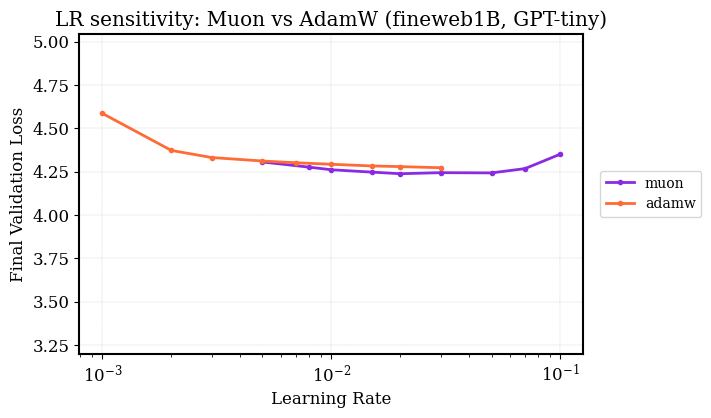

In [11]:
plot_final_loss_vs_lr(baseline_outputs, colormap,
                      outfilename='dap_opnorm_fineweb1B_baselines', val=True)
plt.title('LR sensitivity: Muon vs AdamW (fineweb1B, GPT-tiny)')
plt.show()

## Joint (lr, damping) Sweep: DAPOpNorm, EMA=0.99 (fineweb1B, GPT-tiny)

In [12]:
hydra_base_dap = 'outputs/gpt-tiny/fineweb1B/dap-opnorm'

LR_VALUES      = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 0.15, 0.2]
DAMPING_VALUES = [0.0, 0.001, 0.003, 0.01, 0.03, 0.05, 0.1, 0.3]
EMA_FIXED      = 0.99

def load_joint_sweep(base_dir, lr_values, damping_values, ema_beta):
    results = {}
    all_files = glob.glob(base_dir + '/**/*-world1.json', recursive=True)
    indexed = {}
    for f in all_files:
        d = json.load(open(f))
        hp = d.get('hyperparams', {})
        if hp:
            indexed[(round(hp.get('lr',0), 6), round(hp.get('damping',0), 6),
                     round(hp.get('ema_beta', 0), 6))] = d
    for damping in damping_values:
        for lr in lr_values:
            key = (round(lr, 6), round(damping, 6), round(ema_beta, 6))
            results[(damping, lr)] = indexed.get(key)
    n_found = sum(1 for v in results.values() if v is not None)
    print(f'Loaded {n_found} / {len(lr_values) * len(damping_values)} sweep runs')
    return results

sweep_results = load_joint_sweep(hydra_base_dap, LR_VALUES, DAMPING_VALUES, EMA_FIXED)

Loaded 52 / 72 sweep runs


### HP Landscape Heatmap

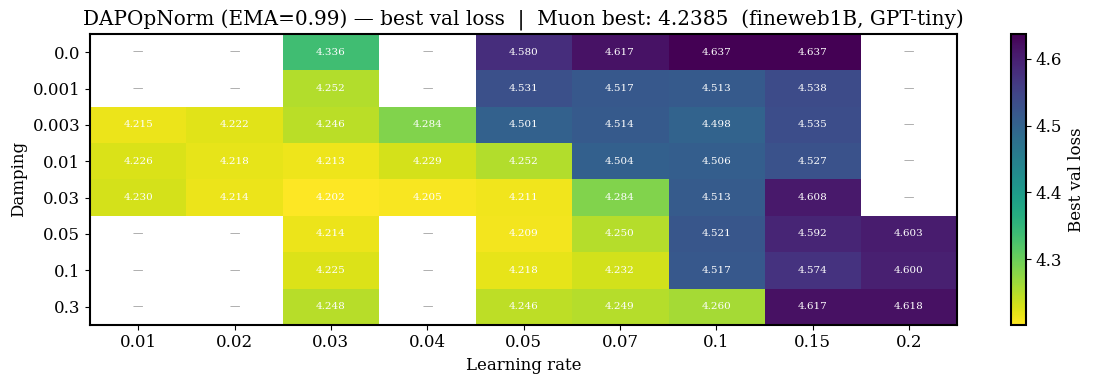

In [13]:
heat_data = np.full((len(DAMPING_VALUES), len(LR_VALUES)), np.nan)
for i, damping in enumerate(DAMPING_VALUES):
    for j, lr in enumerate(LR_VALUES):
        run = sweep_results.get((damping, lr))
        if run is not None:
            heat_data[i, j] = min(run['val_losses'])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(heat_data, aspect='auto', cmap='viridis_r',
               vmin=np.nanmin(heat_data), vmax=min(np.nanmax(heat_data), 4.7))
plt.colorbar(im, ax=ax, label='Best val loss')

ax.set_xticks(range(len(LR_VALUES)))
ax.set_xticklabels([str(lr) for lr in LR_VALUES])
ax.set_yticks(range(len(DAMPING_VALUES)))
ax.set_yticklabels([str(d) for d in DAMPING_VALUES])
ax.set_xlabel('Learning rate')
ax.set_ylabel('Damping')
ax.set_title(f'DAPOpNorm (EMA={EMA_FIXED}) — best val loss  |  Muon best: 4.2385  (fineweb1B, GPT-tiny)')

for i in range(len(DAMPING_VALUES)):
    for j in range(len(LR_VALUES)):
        val = heat_data[i, j]
        text = f'{val:.3f}' if not np.isnan(val) else '—'
        ax.text(j, i, text, ha='center', va='center', fontsize=7.5,
                color='white' if not np.isnan(val) else 'gray')

plt.tight_layout()
plt.savefig('figures/dap_opnorm_fineweb1B_heatmap.pdf', bbox_inches='tight')
plt.show()

### LR Sensitivity by Damping Value

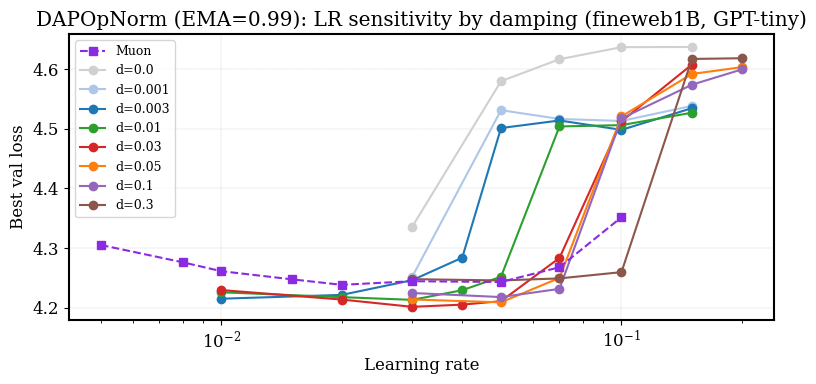

In [17]:
damping_colors = {
    0.0:   '#d0d0d0',
    0.001: '#aec7e8',
    0.003: '#1f77b4',
    0.01:  '#2ca02c',
    0.03:  '#d62728',
    0.05:  '#ff7f0e',
    0.1:   '#9467bd',
    0.3:   '#8c564b',
}

fig, ax = plt.subplots(figsize=(8, 4))

# Muon reference
muon_lrs  = sorted(float(o['name'].rsplit('-lr-', 1)[1]) for o in muon_outputs)
muon_best = [min(o['val_losses']) for o in
             sorted(muon_outputs, key=lambda x: float(x['name'].rsplit('-lr-', 1)[1]))]
ax.plot(muon_lrs, muon_best, color=colormap['muon'], marker='s',
        ls='--', lw=1.5, label='Muon', zorder=5)

for damping in DAMPING_VALUES:
    lrs, best_vals = [], []
    for lr in LR_VALUES:
        run = sweep_results.get((damping, lr))
        if run is not None:
            lrs.append(lr)
            best_vals.append(min(run['val_losses']))
    if lrs:
        ax.plot(lrs, best_vals, marker='o', color=damping_colors[damping],
                label=f'd={damping}')

ax.set_xscale('log')
ax.set_xlabel('Learning rate')
ax.set_ylabel('Best val loss')
ax.set_title(f'DAPOpNorm (EMA={EMA_FIXED}): LR sensitivity by damping (fineweb1B, GPT-tiny)')
ax.legend(fontsize=9)
ax.grid(axis='both', lw=0.2, ls='--')
plt.tight_layout()
plt.savefig('figures/dap_opnorm_fineweb1B_lr_by_damping.pdf', bbox_inches='tight')
plt.show()

### Diagnostics: Preconditioner Norm vs Training Step

`C_inv_sqrt_opnorm` = operator norm of $C^{-1/2}$, i.e. $1/\sqrt{\lambda_{\min}(C_{\text{eff}})}$ where $C_{\text{eff}} = C + \delta \lambda_{\max}(C) I$.

Since damping is **relative** ($\delta \lambda_{\max}$), the condition number is always $\approx 1/\delta$ by construction — so `C_condition` being stable tells us nothing interesting. The opnorm is the real signal: opnorm $\propto 1/\sqrt{\lambda_{\max}(C)}$, so large opnorm means the activation covariance has collapsed to a small scale. At high LR the model is in a poor optimization regime, producing small-scale activations, a large preconditioner, and potentially a positive feedback loop.

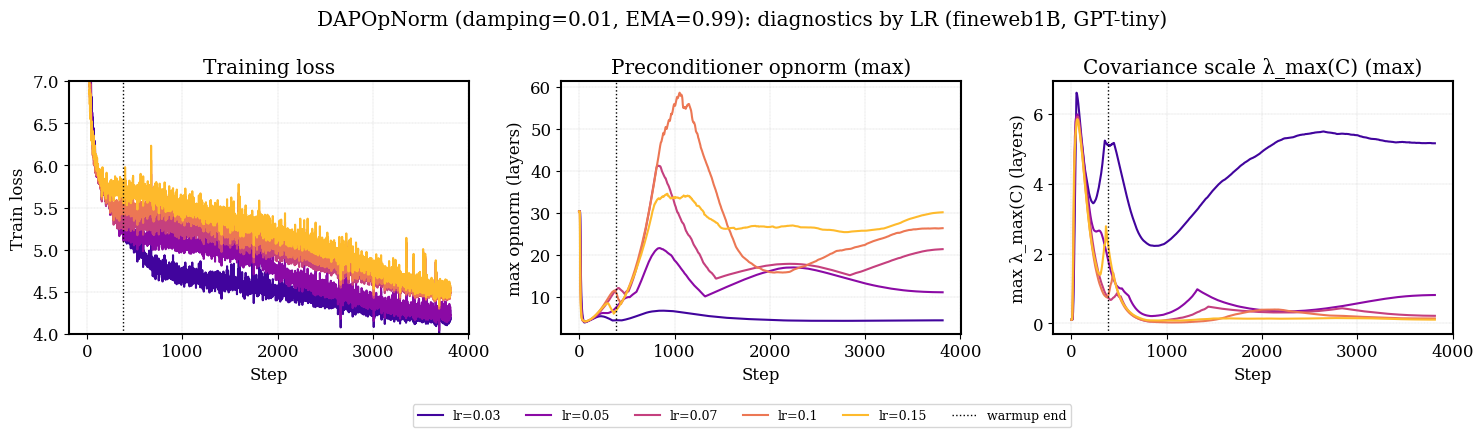

In [15]:
DIAG_DAMPING = 0.01
DIAG_LRS     = [0.03, 0.05, 0.07, 0.1, 0.15]
lr_colors    = plt.cm.plasma(np.linspace(0.1, 0.85, len(DIAG_LRS)))
warmup_step  = int(0.1 * 3814)

def get_opnorm(run):
    """Max opnorm across layers per step."""
    raw = run['diagnostics'].get('C_inv_sqrt_opnorm', [])
    return np.array([max(v) if isinstance(v, list) else v for v in raw])

def get_eigmax(run):
    """λ_max(C) per step: use C_eigmax if available, else infer from C_condition and opnorm."""
    diag = run['diagnostics']
    if 'C_eigmax' in diag:
        raw = diag['C_eigmax']
        return np.array([max(v) if isinstance(v, list) else v for v in raw])
    # Infer: λ_max(C) ≈ C_condition / ((1+damping) * opnorm²)
    cond_raw = diag.get('C_condition', [])
    opnorm   = get_opnorm(run)
    damping  = run['hyperparams']['damping']
    cond = np.array([max(v) if isinstance(v, list) else v for v in cond_raw])
    return cond / ((1 + damping) * opnorm**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
handles = []

for lr, color in zip(DIAG_LRS, lr_colors):
    run = sweep_results.get((DIAG_DAMPING, lr))
    if run is None:
        continue
    losses  = np.array(run.get('losses', []))
    opnorm  = get_opnorm(run)
    eigmax  = get_eigmax(run)
    steps   = np.arange(len(losses))

    l, = axes[0].plot(steps, losses, color=color, lw=1.5, label=f'lr={lr}')
    axes[1].plot(steps, opnorm,  color=color, lw=1.5)
    axes[2].plot(steps, eigmax,  color=color, lw=1.5)
    handles.append(l)

for ax in axes:
    ax.axvline(warmup_step, color='k', ls=':', lw=1)
handles.append(plt.Line2D([0], [0], color='k', ls=':', lw=1, label='warmup end'))

axes[0].set(xlabel='Step', ylabel='Train loss',          title='Training loss',              ylim=(4, 7))
axes[1].set(xlabel='Step', ylabel='max opnorm (layers)', title='Preconditioner opnorm (max)')
axes[2].set(xlabel='Step', ylabel='max λ_max(C) (layers)', title='Covariance scale λ_max(C) (max)')
for ax in axes:
    ax.grid(axis='both', lw=0.2, ls='--')

fig.legend(handles=handles, loc='lower center', ncol=len(handles), fontsize=9,
           bbox_to_anchor=(0.5, -0.08))
plt.suptitle(f'DAPOpNorm (damping={DIAG_DAMPING}, EMA=0.99): diagnostics by LR (fineweb1B, GPT-tiny)')
plt.tight_layout()
plt.savefig('figures/dap_opnorm_fineweb1B_diagnostics.pdf', bbox_inches='tight')
plt.show()

## Best-tuned Loss Curves

Top DAPOpNorm configs:
  damping=0.03, lr=0.03  best_val=4.2016
  damping=0.03, lr=0.04  best_val=4.2053
  damping=0.05, lr=0.05  best_val=4.2092
  damping=0.03, lr=0.05  best_val=4.2111
  damping=0.01, lr=0.03  best_val=4.2133
  damping=0.03, lr=0.02  best_val=4.2138


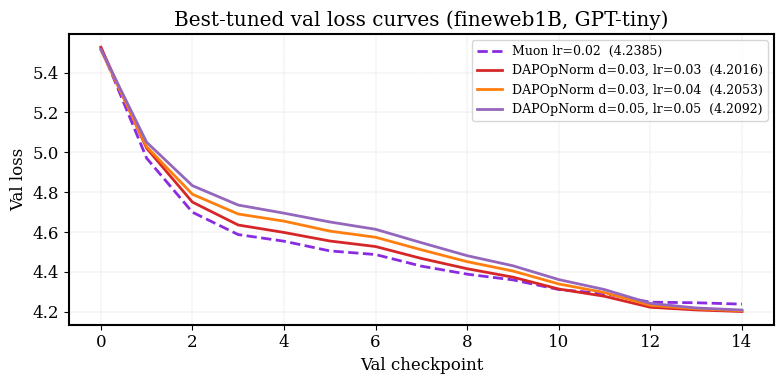

In [16]:
ranked = sorted(
    [(k, v) for k, v in sweep_results.items() if v is not None],
    key=lambda x: min(x[1]['val_losses'])
)

print('Top DAPOpNorm configs:')
for (damping, lr), run in ranked[:6]:
    print(f'  damping={damping}, lr={lr}  best_val={min(run["val_losses"]):.4f}')

top3 = ranked[:3]
best_muon = min(muon_outputs, key=lambda x: min(x['val_losses']))

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(best_muon['val_losses'], color=colormap['muon'], lw=2, ls='--',
        label=f'Muon lr=0.02  ({min(best_muon["val_losses"]):.4f})')

dap_colors_top = ['#d62728', '#ff7f0e', '#9467bd']
for i, ((damping, lr), run) in enumerate(top3):
    ax.plot(run['val_losses'], lw=2, color=dap_colors_top[i],
            label=f'DAPOpNorm d={damping}, lr={lr}  ({min(run["val_losses"]):.4f})')

ax.set_xlabel('Val checkpoint')
ax.set_ylabel('Val loss')
ax.set_title('Best-tuned val loss curves (fineweb1B, GPT-tiny)')
ax.legend(fontsize=9)
ax.grid(axis='both', lw=0.2, ls='--')
plt.tight_layout()
plt.savefig('figures/dap_opnorm_fineweb1B_tuned_curves.pdf', bbox_inches='tight')
plt.show()